## 📊 Análise de Rentabilidade e Impacto de Descontos

## 🎯 Objetivo

Este projeto tem como objetivo analisar a rentabilidade dos produtos e identificar como a estratégia de descontos impacta o lucro da empresa.

A análise busca responder:

- Quais produtos geram prejuízo?
- O prejuízo está relacionado à falta de vendas ou à estratégia comercial?
- Qual o impacto dos descontos na margem?
- Existem padrões por categoria ou região?

O foco principal é gerar insights estratégicos que apoiem decisões de negócio e melhoria da rentabilidade.

Importação da base

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

import os
os.makedirs('imagens', exist_ok=True)

plt.style.use('seaborn-v0_8')

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [14]:
# Remover linhas duplicadas
df = df.drop_duplicates()

# Verificar valores nulos
df.isnull().sum()

# Verificar os tipos de dados
df = df.dropna()


In [15]:
# Converter as colunas 'Order Date' e 'Ship Date' para o tipo datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Converter as colunas 'Sales', 'Profit', 'Discount' e 'Quantity' para os tipos numéricos adequados 

df['Sales'] = df['Sales'].astype(float)
df['Profit'] = df['Profit'].astype(float)
df['Discount'] = df['Discount'].astype(float)
df['Quantity'] = df['Quantity'].astype(int)

In [16]:
# Padronizar os valores das colunas 'Region', 'Category' e 'Product Name' (remover espaços em branco e converter para título)

df['Region'] = df['Region'].str.strip().str.title()
df['Category'] = df['Category'].str.strip().str.title()
df['Product Name'] = df['Product Name'].str.strip()


In [17]:
# Filtrar os dados para remover vendas com valores de 'Sales' ou 'Quantity' iguais ou menores que zero

df = df[df['Sales'] > 0]
df = df[df['Quantity'] > 0]

In [18]:
# Filtrar os dados para remover vendas com valores de 'Discount' menores que 0 ou maiores que 1

df = df[df['Discount'] >= 0]
df = df[df['Discount'] <= 1]

In [19]:
#   Criar colunas de 'Ano' e 'Mês' a partir da coluna 'Order Date'

df['Ano'] = df['Order Date'].dt.year
df['Mes'] = df['Order Date'].dt.month

In [20]:
# Reindexar o DataFrame após as operações de limpeza

df = df.reset_index(drop=True)

In [21]:
# Salvar o DataFrame tratado em um novo arquivo CSV para uso posterior  

import os
os.makedirs('data', exist_ok=True)

df.to_csv('data/dados_tratados.csv', index=False)

DataFrame

### 📊 Preparação dos Dados

Os dados foram agregados por produto, consolidando vendas, lucro e desconto médio, permitindo análise estratégica por item.

In [33]:

df_group = df.groupby('Product Name')[['Sales','Profit','Discount']].agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

## Vendas geral - Vendas por categoria

🧠 Análise

Essa visualização apresenta a distribuição do volume de vendas entre as categorias de produtos.

💡 Insight

A categoria Technology concentra o maior volume de vendas
Office Supplies apresenta volume relevante
Furniture também possui alta participação

📊 Interpretação

O negócio possui forte geração de receita concentrada em algumas categorias, indicando foco comercial bem definido.

Essa visão inicial é essencial para entender o tamanho do negócio antes de analisar a rentabilidade.

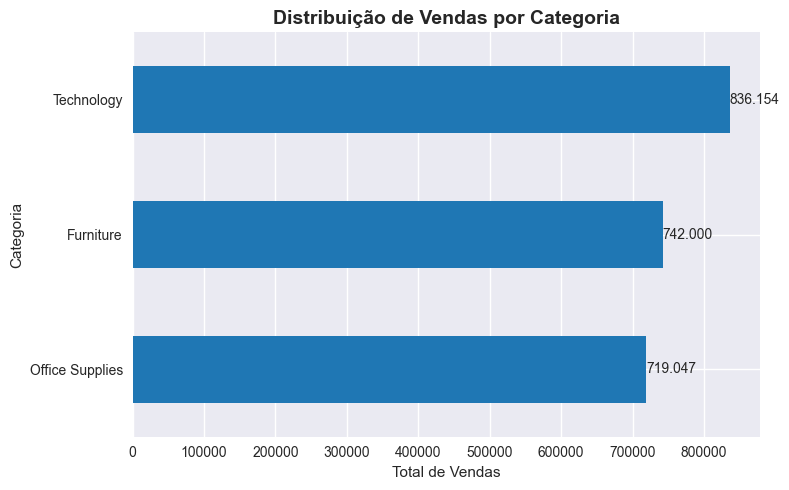

In [34]:
# Vendas por categoria
df_categoria_vendas = df.groupby('Category')['Sales'].sum().sort_values()

# Gráfico

plt.figure(figsize=(8,5))

df_categoria_vendas.plot(
    kind='barh',
    color='#1f77b4'
)

plt.title('Distribuição de Vendas por Categoria', fontsize=14, weight='bold')
plt.xlabel('Total de Vendas')
plt.ylabel('Categoria')

# limpar visual
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# valores nas barras
for i, v in enumerate(df_categoria_vendas):
    plt.text(v, i, f'{v:,.0f}'.replace(',', '.'), va='center')

plt.tight_layout()

plt.savefig('imagens/grafico_vendas_categoria.png', dpi=300, bbox_inches='tight')
plt.show()




## PERFORMANCE — VENDAS vs LUCRO

Análise

O gráfico compara o volume de vendas com o lucro gerado por cada categoria.

💡 Insight

Technology apresenta alto volume de vendas e alto lucro
Office Supplies mantém boa relação entre vendas e lucratividade
Furniture, apesar de vender bem, apresenta lucro significativamente menor

📊 Interpretação

Nem toda venda gera lucro proporcional.

A categoria de Furniture demonstra um desequilíbrio entre receita e rentabilidade, indicando possível problema na estratégia de precificação ou descontos.

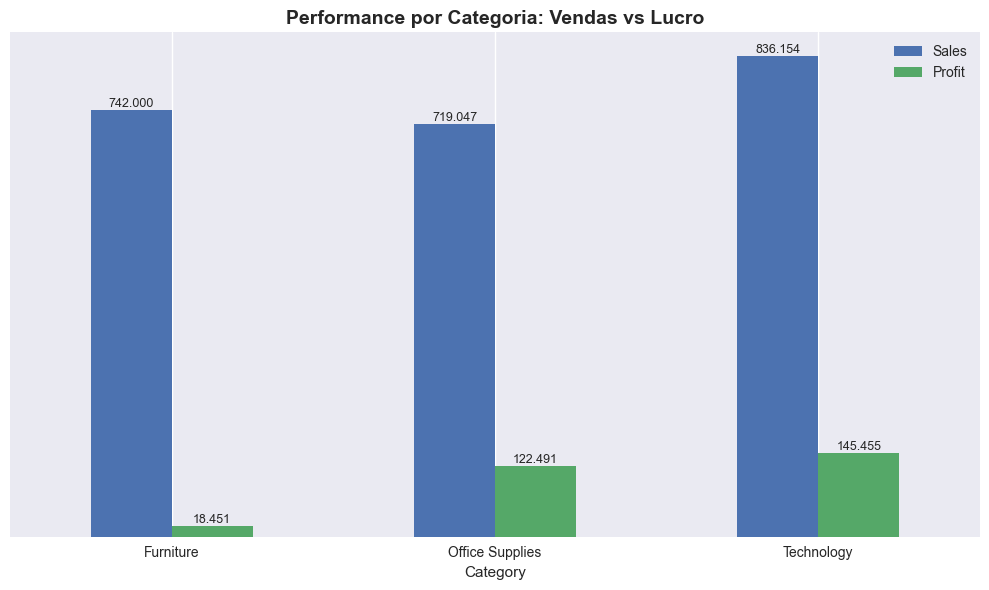

In [24]:
df_categoria_perf = df.groupby('Category')[['Sales', 'Profit']].sum()

fig, ax = plt.subplots(figsize=(10,6))

# barras
df_categoria_perf.plot(
    kind='bar',
    ax=ax
)

plt.title('Performance por Categoria: Vendas vs Lucro', fontsize=14, weight='bold')
plt.xticks(rotation=0)

# limpar eixo Y
ax.set_yticks([])

# valores nas barras
for p in ax.patches:
    height = p.get_height()
    if height != 0:
        ax.annotate(
            f'{height:,.0f}'.replace(',', '.'),
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=9
        )

# limpeza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('imagens/vendas_lucro.png', dpi=300, bbox_inches='tight')
plt.show()

## Prejuizo

### 📊 O que está sendo analisado

Nesta etapa, foram identificados os produtos com maior prejuízo acumulado, considerando o lucro total por produto.

### 📈 Insight

A análise mostra que existem produtos com prejuízo significativo, mesmo apresentando volume de vendas.

Isso indica que o problema não está necessariamente na demanda, mas possivelmente na estratégia de precificação ou nos descontos aplicados.

### 💡 Interpretação

Produtos que vendem e ainda assim geram prejuízo representam um risco direto para a empresa, pois ampliam perdas financeiras à medida que o volume aumenta.

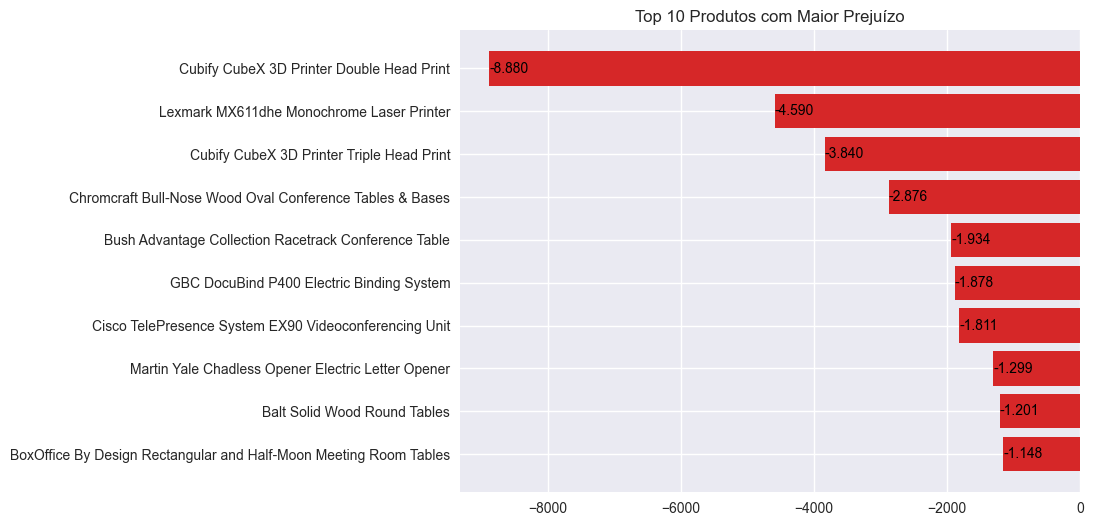

In [25]:
top_prejuizo = df_group.sort_values(by='Profit').head(10)

plt.figure(figsize=(8,6))
plt.barh(top_prejuizo['Product Name'], top_prejuizo['Profit'], color='#d62728')
plt.title('Top 10 Produtos com Maior Prejuízo')
plt.gca().invert_yaxis()

# 💰 VALORES NAS BARRAS
# =========================
for i, v in enumerate(top_prejuizo['Profit']):
    plt.text(
        v,            # posição no eixo X
        i,            # posição no eixo Y
        f'{v:,.0f}'.replace(',', '.'), 
        va='center',
        color='black'
    )

plt.savefig('imagens/grafico_prejuizo.png', dpi=300, bbox_inches='tight')
plt.show()

## DASHBOARD 

### 📊 O que está sendo analisado

Foi desenvolvido um dashboard para analisar a relação entre vendas, lucro e desconto, com foco em produtos que apresentam prejuízo.

### 📈 Insight

O gráfico de dispersão evidencia que existem produtos com alto volume de vendas, mas com lucro negativo.

Além disso, os produtos com maior prejuízo apresentam níveis elevados de desconto.

### 💡 Interpretação

Os dados indicam que o prejuízo não está relacionado à falta de vendas, mas sim à estratégia comercial adotada.

Descontos excessivos estão comprometendo a margem, fazendo com que o aumento das vendas amplifique as perdas.

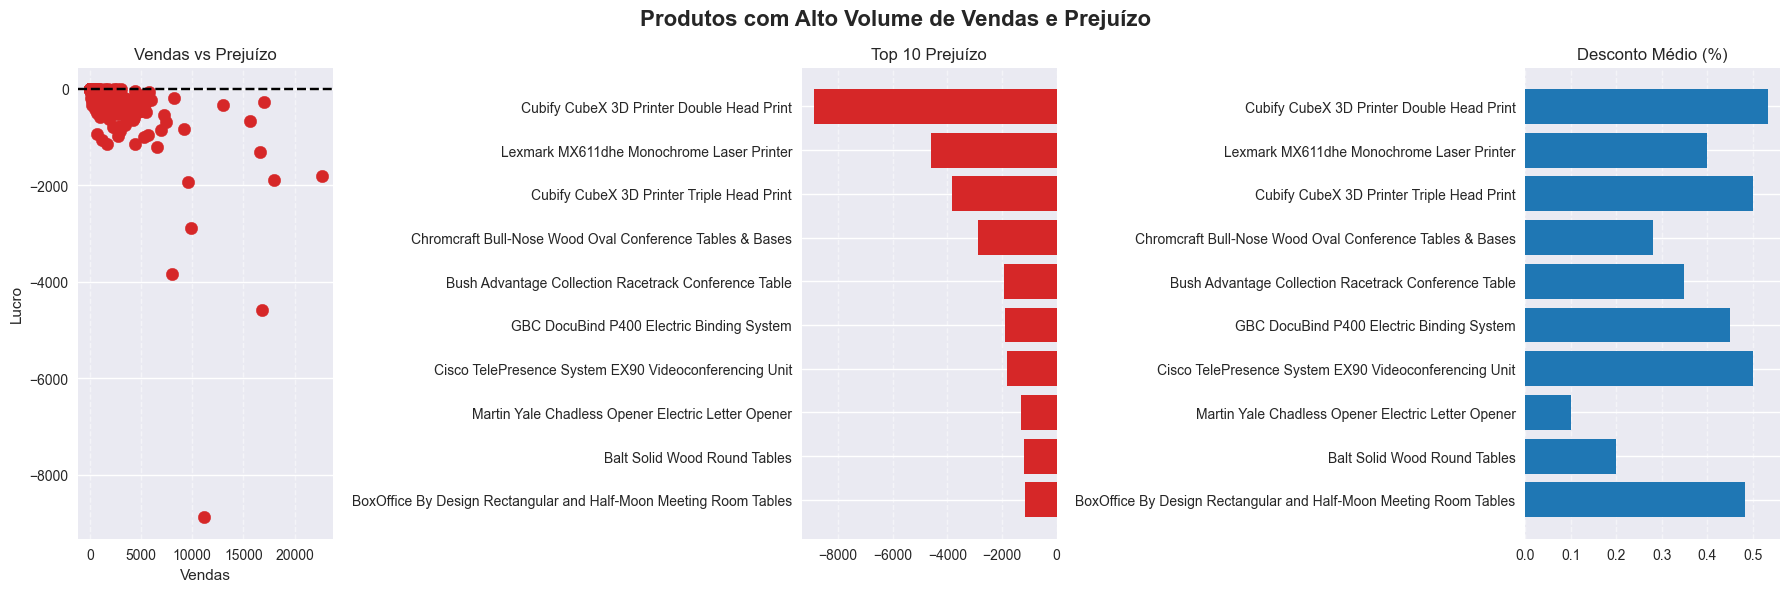

In [26]:
cor_prejuizo = '#d62728'
cor_vendas = '#1f77b4'

df_prejuizo = df_group[df_group['Profit'] < 0]
top10 = df_prejuizo.sort_values(by='Profit').head(10)

fig, axes = plt.subplots(1, 3, figsize=(18,6))

fig.suptitle('Produtos com Alto Volume de Vendas e Prejuízo', fontsize=16, fontweight='bold')

# Scatter
axes[0].scatter(df_prejuizo['Sales'], df_prejuizo['Profit'], color=cor_prejuizo, s=80)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Vendas vs Prejuízo')

# Top prejuízo
axes[1].barh(top10['Product Name'], top10['Profit'], color=cor_prejuizo)
axes[1].set_title('Top 10 Prejuízo')
axes[1].invert_yaxis()

# Desconto
axes[2].barh(top10['Product Name'], top10['Discount'], color=cor_vendas)
axes[2].set_title('Desconto Médio (%)')
axes[2].invert_yaxis()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

axes[0].set_xlabel('Vendas')
axes[0].set_ylabel('Lucro')    

plt.tight_layout()

plt.savefig('imagens/dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## Lucro

## 💰 Análise de Produtos Mais Lucrativos

### 📊 O que está sendo analisado

Foram identificados os produtos com maior lucro acumulado, considerando o total gerado por cada item.

### 📈 Insight

Alguns produtos apresentam alta lucratividade e contribuem de forma significativa para o resultado da empresa.

### 💡 Interpretação

Esses produtos possuem melhor equilíbrio entre preço, custo e desconto, sendo estratégicos para o crescimento sustentável do negócio.

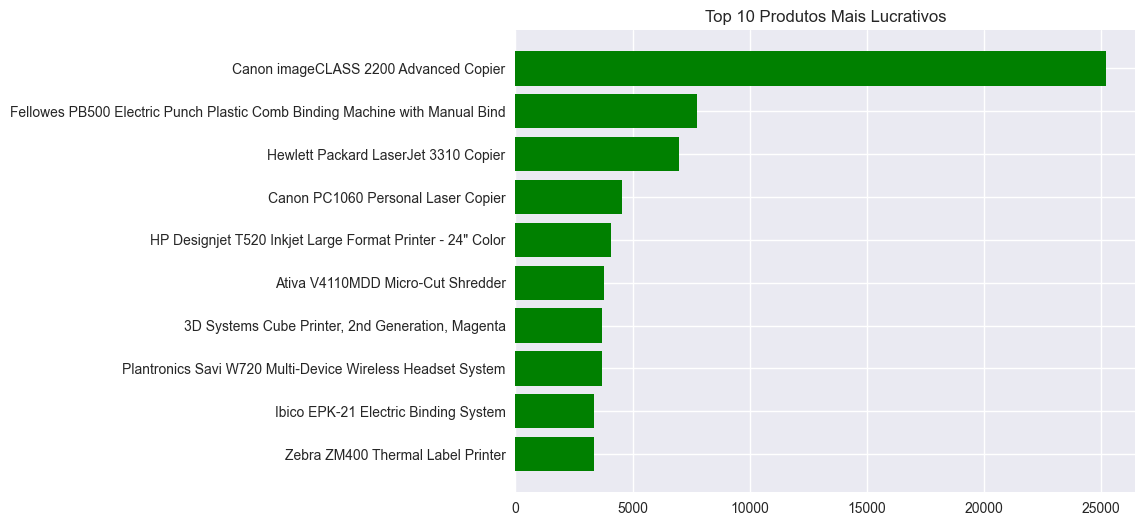

In [27]:
top_lucro = df_group.sort_values(by='Profit', ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(top_lucro['Product Name'], top_lucro['Profit'], color='green')
plt.title('Top 10 Produtos Mais Lucrativos')
plt.gca().invert_yaxis()

plt.savefig('imagens/lucro.png', dpi=300, bbox_inches='tight')
plt.show()

## Margem

## 📉 Análise de Margem de Lucro

### 📊 O que está sendo analisado

Foi calculada a margem de lucro (Profit / Sales) para identificar produtos com pior desempenho relativo.

### 📈 Insight

Existem produtos com margens extremamente baixas ou negativas, mesmo quando apresentam vendas relevantes.

### 💡 Interpretação

Isso indica problemas estruturais na precificação ou nos custos, sendo um sinal de alerta para revisão estratégica.

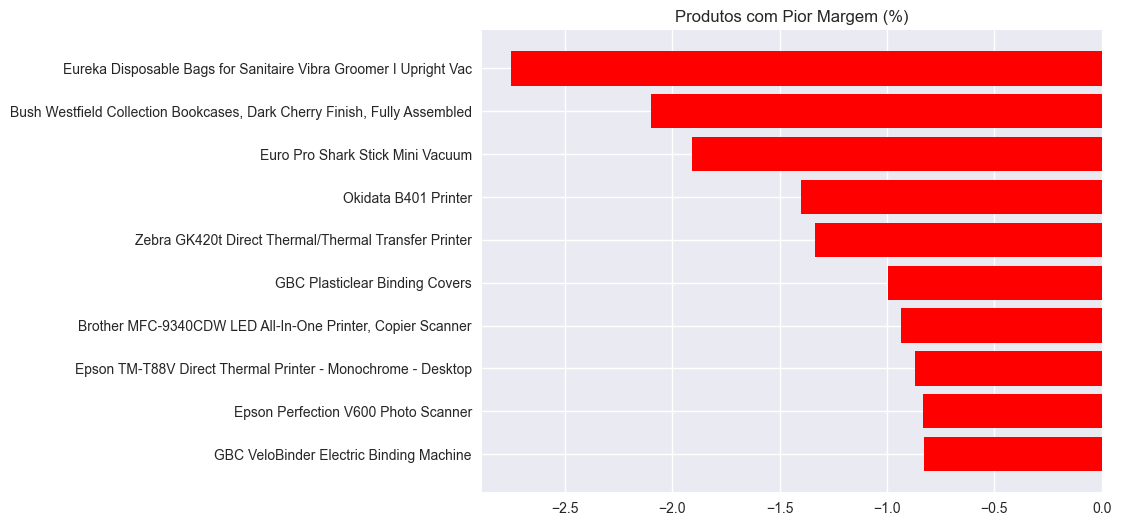

In [28]:
df_group['Margin'] = df_group['Profit'] / df_group['Sales']

top_margin = df_group.sort_values(by='Margin').head(10)

plt.figure(figsize=(8,6))
plt.barh(top_margin['Product Name'], top_margin['Margin'], color='red')
plt.title('Produtos com Pior Margem (%)')
plt.gca().invert_yaxis()

plt.savefig('imagens/margem.png', dpi=300, bbox_inches='tight')
plt.show()

## Categoria

### 📊 O que está sendo analisado

A análise por categoria busca entender o desempenho de vendas, lucro e desconto em cada grupo de produtos.

### 📈 Insight

- A categoria de Móveis apresenta alto volume de vendas, porém baixa lucratividade  
- Tecnologia apresenta alta lucratividade com menor nível de desconto  
- Suprimentos de Escritório mantém bom lucro mesmo com descontos elevados  

### 💡 Interpretação

Os resultados indicam que o impacto dos descontos varia por categoria.

Enquanto alguns produtos suportam descontos sem comprometer o lucro, outros têm sua margem fortemente afetada.

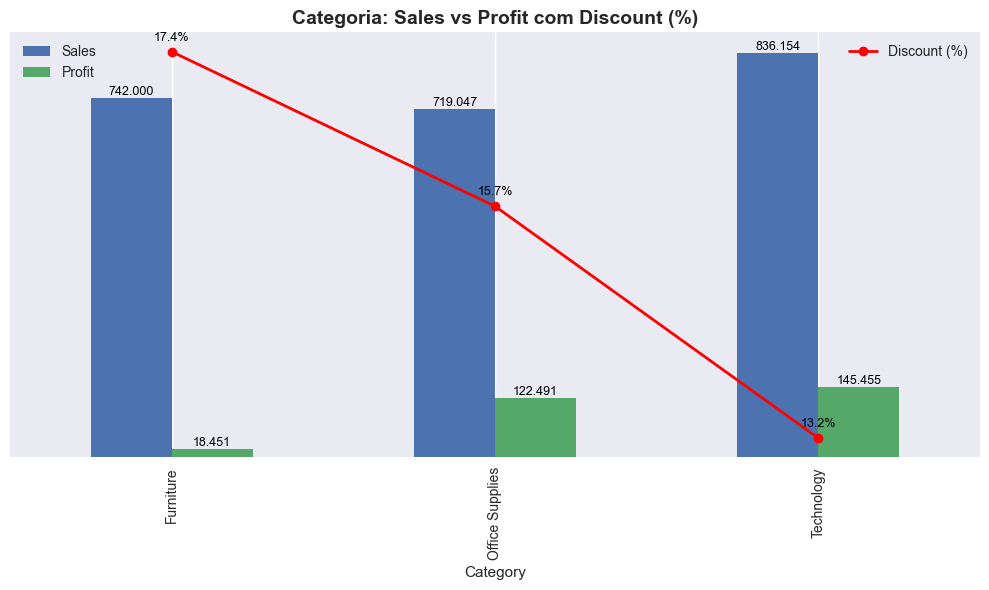

In [29]:
df_categoria = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
})

# Converter desconto para %
df_categoria['Discount_pct'] = df_categoria['Discount'] * 100

fig, ax = plt.subplots(figsize=(10,6))

# =========================
# 📊 BARRAS
# =========================
df_categoria[['Sales', 'Profit']].plot(
    kind='bar',
    ax=ax
)

# =========================
# 📈 LINHA
# =========================
ax2 = ax.twinx()

df_categoria['Discount_pct'].plot(
    kind='line',
    color='red',
    marker='o',
    linewidth=2,
    ax=ax2
)

# =========================
# 🧠 LIMPEZA (REMOVE EIXOS)
# =========================
ax.set_yticks([])
ax2.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.title('Categoria: Sales vs Profit com Discount (%)', fontsize=14, weight='bold')
plt.xticks(rotation=0)

# =========================
# 💰 VALORES NAS BARRAS (PRETO)
# =========================
for p in ax.patches:
    height = p.get_height()
    if height != 0:
        ax.annotate(
            f'{height:,.0f}'.replace(',', '.'),
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# =========================
# 🔴 VALORES NA LINHA (PRETO)
# =========================
for i, value in enumerate(df_categoria['Discount_pct']):
    ax2.annotate(
        f'{value:.1f}%',
        (i, value),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        fontsize=9,
        color='black'
    )

# =========================
# 📌 LEGENDAS
# =========================
ax.legend(loc='upper left')
ax2.legend(['Discount (%)'], loc='upper right')

plt.tight_layout()

plt.savefig('imagens/categoria.png', dpi=300, bbox_inches='tight')
plt.show()

## Região

### 📊 O que está sendo analisado

Foi analisado o desempenho de vendas, lucro e desconto em diferentes regiões.

### 📈 Insight

- A região West apresenta maior volume de vendas e lucro  
- A região Central apresenta altos descontos, mas baixo retorno em lucro  
- A região South demonstra maior equilíbrio entre vendas e rentabilidade  

### 💡 Interpretação

Os dados mostram que o nível de desconto impacta diretamente a rentabilidade regional.

Regiões com maior desconto não necessariamente apresentam melhor desempenho, indicando ineficiência na estratégia comercial.

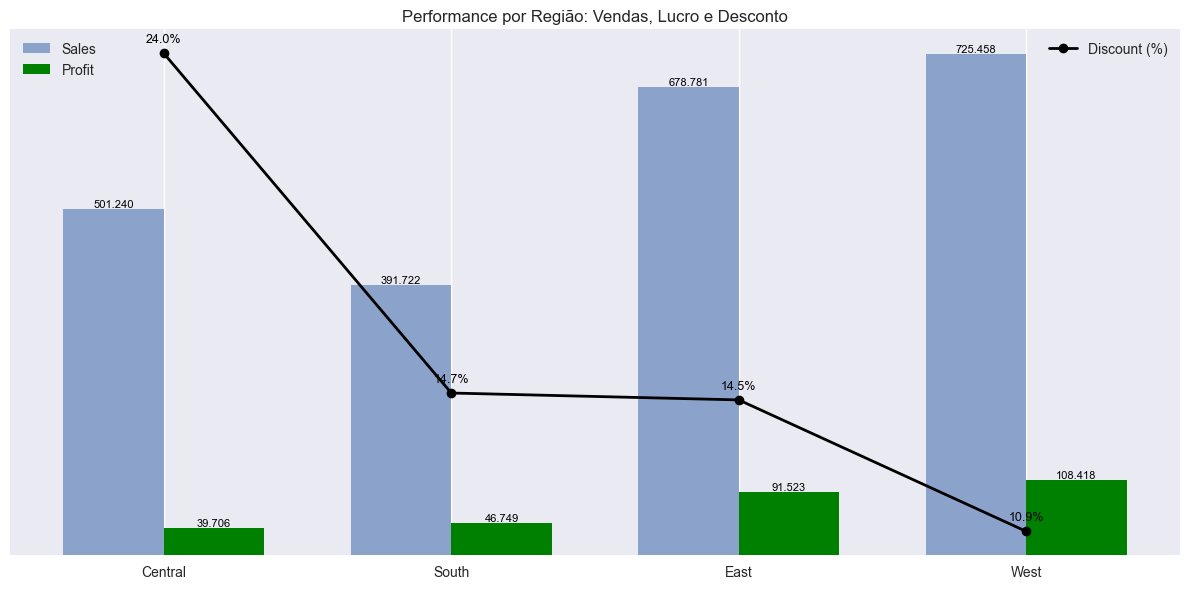

In [30]:
df_regiao = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

df_regiao = df_regiao.sort_values(by='Profit')

# Converter desconto para %
df_regiao['Discount_pct'] = df_regiao['Discount'] * 100

cores_profit = ['red' if x < 0 else 'green' for x in df_regiao['Profit']]

fig, ax = plt.subplots(figsize=(12,6))

# =========================
# 📊 BARRAS (SEPARADAS)
# =========================
x = range(len(df_regiao))

bar_width = 0.35

bars1 = ax.bar(
    [i - bar_width/2 for i in x],
    df_regiao['Sales'],
    width=bar_width,
    label='Sales',
    alpha=0.6
)

bars2 = ax.bar(
    [i + bar_width/2 for i in x],
    df_regiao['Profit'],
    width=bar_width,
    color=cores_profit,
    label='Profit'
)

# =========================
# 📈 LINHA
# =========================
ax2 = ax.twinx()

ax2.plot(
    x,
    df_regiao['Discount_pct'],
    color='black',
    marker='o',
    linewidth=2,
    label='Discount (%)'
)

# =========================
# 🧠 LIMPEZA
# =========================
ax.set_yticks([])
ax2.set_yticks([])

ax.set_xticks(x)
ax.set_xticklabels(df_regiao['Region'])

plt.title('Performance por Região: Vendas, Lucro e Desconto')

ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# =========================
# 💰 VALORES NAS BARRAS (SEM SOBREPOSIÇÃO)
# =========================
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

# =========================
# 🔴 VALORES NA LINHA (AGORA CORRETO)
# =========================
for i, value in enumerate(df_regiao['Discount_pct']):
    ax2.annotate(
        f'{value:.1f}%',
        (i, value),
        textcoords="offset points",
        xytext=(0,8),
        ha='center',
        color='black',
        fontsize=9
    )

plt.tight_layout()

plt.savefig('imagens/regiao.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlação

In [31]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


## 📉 Relação entre Desconto e Lucro

### 📊 O que está sendo analisado

Foi calculada a correlação entre desconto e lucro para entender a relação entre essas variáveis.

### 📈 Insight

A correlação negativa indica que, à medida que o desconto aumenta, o lucro tende a diminuir.

### 💡 Interpretação

Isso reforça que a estratégia de desconto está impactando negativamente a rentabilidade da empresa.



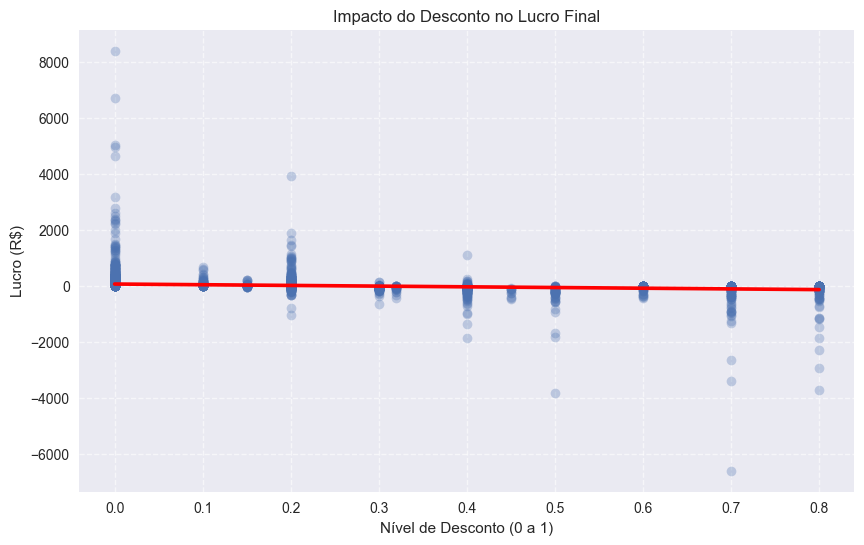

In [32]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# O regplot desenha os pontos E a linha de tendência que "resume" a direção dos dados
sns.regplot(data=df, x='Discount', y='Profit', 
            scatter_kws={'alpha':0.3}, 
            line_kws={'color':'red'})

plt.title('Impacto do Desconto no Lucro Final')
plt.xlabel('Nível de Desconto (0 a 1)')
plt.ylabel('Lucro (R$)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('imagens/correlacao.png', dpi=300, bbox_inches='tight')

plt.show()

### 📈 Insight

O gráfico mostra uma tendência negativa entre desconto e lucro.

### 💡 Interpretação

À medida que o desconto aumenta, o lucro tende a diminuir, indicando impacto direto na rentabilidade.

Isso sugere que o aumento de descontos não está sendo compensado por aumento proporcional nas vendas, indicando uma estratégia comercial potencialmente prejudicial à lucratividade.

# 💣 Conclusão

A análise revelou que o principal problema não está na geração de receita, mas sim na rentabilidade.

Produtos com alto volume de vendas estão gerando prejuízo devido a políticas de desconto agressivas e possíveis falhas na precificação.

Além disso, regiões e categorias com maior nível de desconto não apresentam retorno proporcional em lucro, evidenciando ineficiência na estratégia comercial.

### 🚀 Visão Estratégica

Os resultados indicam que o crescimento em vendas não está sendo acompanhado por crescimento em rentabilidade.

A empresa apresenta um padrão crítico: aumento de volume aliado à redução de margem, impulsionado principalmente por descontos elevados.

👉 Em outras palavras:  
Vender mais, do jeito atual, pode significar perder mais dinheiro.

Portanto, a prioridade estratégica deve ser a otimização da margem, e não apenas o aumento do volume de vendas.

### 💡 Recomendações

- Revisar a política de descontos, principalmente nos produtos críticos  
- Reavaliar a precificação com foco em margem  
- Monitorar produtos com alto volume e baixa rentabilidade  
- Priorizar produtos mais lucrativos em campanhas comerciais  

A análise permite direcionar ações estratégicas com foco em crescimento sustentável e aumento da lucratividade.